In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy from Drive to local VM
!cp /content/drive/MyDrive/PlantAI/PlantVillage.zip /content/PlantVillage.zip

# Unzip locally
!unzip -q /content/PlantVillage.zip -d /content/dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define the folder where images are
DATA_PATH = '/content/dataset/PlantVillage'

# Setup Generator with Shuffling (Fixes the 50% accuracy bug)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    DATA_PATH, target_size=(224, 224), batch_size=32,
    subset='training', shuffle=True, seed=42
)

val_gen = datagen.flow_from_directory(
    DATA_PATH, target_size=(224, 224), batch_size=32,
    subset='validation', shuffle=True, seed=42
)

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.


In [ ]:
# Use MobileNetV2 (Reliable & Fast)
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# THIS IS YOUR INSURANCE POLICY
checkpoint_path = "/content/drive/MyDrive/PlantAI/best_model.keras"
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_accuracy'
)

# Start Training
model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[checkpoint_cb])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 108s 88ms/step - accuracy: 0.5298 - loss: 1.2327 - val_accuracy: 0.2226 - val_loss: 2.8951
Epoch 2/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 65s 63ms/step - accuracy: 0.5509 - loss: 0.9277 - val_accuracy: 0.2324 - val_loss: 2.9161
Epoch 3/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 70s 68ms/step - accuracy: 0.5582 - loss: 0.8849 - val_accuracy: 0.2835 - val_loss: 3.5411
Epoch 4/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 65s 63ms/step - accuracy: 0.5566 - loss: 0.8686 - val_accuracy: 0.2186 - val_loss: 3.6247
Epoch 5/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 64s 62ms/step - accuracy: 0.5622 - loss: 0.8451 - val_accuracy: 0.2640 - val_loss: 3.9850
Epoch 6/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 65s 62ms/step - accuracy: 0.5599 - loss: 0.8402 - val_accuracy: 0.2061 - val_loss: 4.0107
Epoch 7/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 62s 60ms/step - accuracy: 0.5662 - loss: 0.8248 - val_accuracy: 0.1984 - val_loss: 4.2584
Epoch 8/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 65s 63ms/step - accuracy: 0.5646 

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. SETUP DATA WITH AGGRESSIVE AUGMENTATION
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      # Rotate leaves
    width_shift_range=0.2,  # Move leaves around
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,         # Zoom in on spots
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset/PlantVillage',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    '/content/dataset/PlantVillage',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

# 2. BUILD THE MODEL WITH UNFROZEN LAYERS
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the last 20 layers of the "brain"
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3), # Prevents memorization
    tf.keras.layers.Dense(train_gen.num_classes, activation='softmax')
])

# 3. USE A SLOWER LEARNING RATE (To carefully learn spots)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. SAVE TO DRIVE CALLBACK
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/PlantAI/best_model_v2.keras",
    save_best_only=True,
    monitor='val_accuracy'
)

print("🌿 Starting Deep Training...")
model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[checkpoint_cb])

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.
🌿 Starting Deep Training...
Epoch 1/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 531s 500ms/step - accuracy: 0.4989 - loss: 1.4921 - val_accuracy: 0.3444 - val_loss: 2.8520
Epoch 2/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 498s 483ms/step - accuracy: 0.5481 - loss: 0.9659 - val_accuracy: 0.2605 - val_loss: 3.5730
Epoch 3/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 497s 482ms/step - accuracy: 0.5591 - loss: 0.8893 - val_accuracy: 0.1685 - val_loss: 4.3199
Epoch 4/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 499s 484ms/step - accuracy: 0.5582 - loss: 0.8450 - val_accuracy: 0.1879 - val_loss: 4.7341
Epoch 5/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 499s 483ms/step - accuracy: 0.5590 - loss: 0.8284 - val_accuracy: 0.1797 - val_loss: 4.7644
Epoch 6/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 501s 485ms/step - accuracy: 0.5606 - loss: 0.8049 - val_accuracy: 0.1667 - val_loss: 4.7012
Epoch 7/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 500s 484ms/step - accuracy: 0.5642 - lo

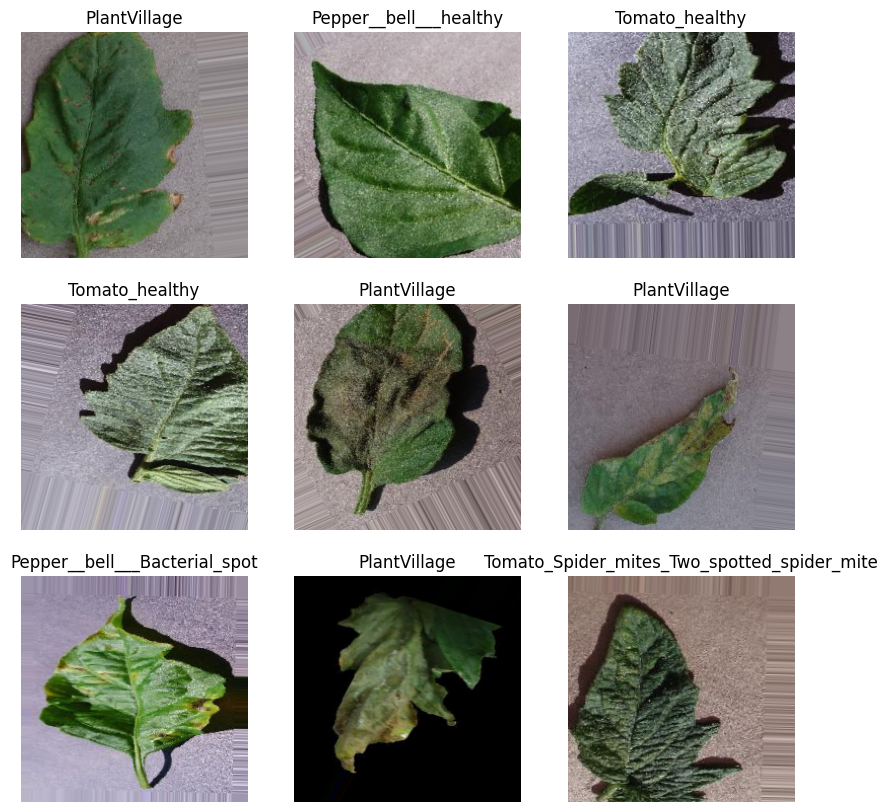

In [ ]:
import numpy as np # Added this to fix your error!
import matplotlib.pyplot as plt

# Get a batch of images
x_batch, y_batch = next(train_gen)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    # Undo the 1/255 rescaling just for the display so it's not dark/weird
    plt.imshow(x_batch[i])

    class_idx = np.argmax(y_batch[i])
    class_label = list(train_gen.class_indices.keys())[class_idx]
    plt.title(class_label)
    plt.axis('off')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. TARGET THE CORRECT SUB-DIRECTORY
# Based on your diagnostic, the real images are one level deeper
BASE_PATH = '/content/dataset/PlantVillage'

# Let's fix the path if there's a nested folder
subfolders = os.listdir(BASE_PATH)
if 'PlantVillage' in subfolders:
    # If there's a folder named PlantVillage inside, we use that instead
    BASE_PATH = os.path.join(BASE_PATH, 'PlantVillage')

print(f"✅ Training on folders found in: {BASE_PATH}")

# 2. SHUFFLED GENERATORS
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    batch_size=32,
    subset='training',
    shuffle=True,
    seed=123 # This ensures random mixing
)

val_gen = datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    batch_size=32,
    subset='validation',
    shuffle=True,
    seed=123
)

# 3. BUILD STABLE MODEL
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. START (Expect a breakthrough now!)
model.fit(train_gen, validation_data=val_gen, epochs=5)

✅ Training on folders found in: /content/dataset/PlantVillage/PlantVillage
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 279s 522ms/step - accuracy: 0.5590 - loss: 1.4470 - val_accuracy: 0.8379 - val_loss: 0.5175
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 238s 460ms/step - accuracy: 0.8500 - loss: 0.4779 - val_accuracy: 0.8780 - val_loss: 0.3751
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 241s 467ms/step - accuracy: 0.8819 - loss: 0.3668 - val_accuracy: 0.9000 - val_loss: 0.3141
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 236s 457ms/step - accuracy: 0.9059 - loss: 0.2850 - val_accuracy: 0.9153 - val_loss: 0.2760
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 239s 462ms/step - accuracy: 0.9228 - loss: 0.2477 - val_accuracy: 0.9102 - val_loss: 0.2636


In [ ]:
import tensorflow as tf

# 1. Initialize the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. Apply optimizations (makes the model smaller/faster)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Convert the model
tflite_model = converter.convert()

# 4. Save the .tflite file to your Google Drive
tflite_save_path = '/content/drive/MyDrive/PlantAI/plant_model.tflite'
with open(tflite_save_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Success! TFLite model saved to: {tflite_save_path}")

Saved artifact at '/tmp/tmpl3jjawcq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_471')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  132417848443152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848444496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848444304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848443728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848445072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848443344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848444688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848444880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848443920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848446032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132417848

In [ ]:
# Create labels file
class_names = sorted(train_gen.class_indices.items(), key=lambda x: x[1])
with open('/content/drive/MyDrive/PlantAI/labels.txt', 'w') as f:
    for name, index in class_names:
        f.write(f"{name}\n")
print("✅ labels.txt created! Download this along with your .tflite file.")

✅ labels.txt created! Download this along with your .tflite file.
